# Daniel Rojo Mata
# Aprendizaje Automatizado, Tarea 2

# **PROBLEMA 1: Predicción de precios de automóviles**

A partir del conjunto de datos *Automobile Dataset*, realiza la regresión de los precios de automóviles con las siguientes variantes:

**a.** Mínimos cuadrados con expansión polinomial de diferentes grados.  
**b.** Mínimos cuadrados con expansión polinomial de grado 20 y penalización por norma L1 y L2 con diferentes valores de λ.  
**c.** Mínimos cuadrados con expansión polinomial de grado 2 y selección de atributos.

Grafica el error cuadrático medio en entrenamiento y validación con respecto al grado del polinomio, valor de λ y número de atributos.  
Todos los modelos deberán ser evaluados con 10 repeticiones de validación cruzada de 5 particiones.  
Selecciona uno de los modelos y reporta su desempeño en el conjunto de prueba.


## Se importan las librerías

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np
# Visualización
import matplotlib.pyplot as plt
# Ignorar advertencias
import warnings
warnings.filterwarnings('ignore')
# Preprocesamiento
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# Modelos de regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso
# Validación cruzada y división
from sklearn.model_selection import train_test_split, RepeatedKFold
# Métricas de evaluación
from sklearn.metrics import mean_squared_error, r2_score
# Selección de atributos
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, r_regression, RFE
# Codificación categórica
import category_encoders as ce

# **SOLUCIÓN INCISO a)**

## Se importa y se limpia la data  

### **Paso 1**: Cargar el archivo y reemplazar `"?"` por `NaN`

**Objetivo:**  
Cargar correctamente el dataset y reemplazar los valores faltantes representados por `"?"` con `NaN`, que es el formato estándar para valores nulos en pandas.

**Acción realizada:**
- Se utilizó el parámetro `na_values="?"` dentro de `pd.read_csv()` para que pandas detecte automáticamente los `"?"` como `NaN`.
- También se asignaron manualmente los nombres de las columnas utilizando el argumento `names=`, ya que el archivo no contiene encabezados (`header=None`).

**Ventajas:**
- Facilita el tratamiento de valores faltantes en etapas posteriores.
- Tener nombres de columnas descriptivos mejora la legibilidad del código y facilita el análisis posterior.

In [2]:
# Leer el archivo CSV y reemplazar los "?" por valores nulos (NaN)
# Nombre de las columnas.
# Se consultaron en la documentación oficial del DataSet
column_names = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]

ruta = "data_carros.csv"
data = pd.read_csv(ruta,
                   na_values="?", # los valores con "?" se transforman a NaN
                   names=column_names # cambiamos el nombre a las columnas
                  )

# OPCIONAL: 
#print(data.columns.tolist())
# OPCIONAL: 
# Verificar rápidamente cuántos valores faltantes hay por columna
#print(data.isna().sum())

### **Paso 2**: Conversión de columnas numéricas con valores faltantes a tipo `float`

**Objetivo:**  
Convertir las columnas numéricas con valores faltantes a tipo `float`, para poder realizar imputaciones, análisis estadístico y entrenar modelos de regresión correctamente.

**Columnas convertidas:**
- `normalized-losses`
- `bore`
- `stroke`
- `horsepower`
- `peak-rpm`
- `price`

**¿Por qué hacerlo?**
- Estas columnas pueden contener valores faltantes (`NaN`) provenientes de caracteres `"?"`.
- Si no se convierten, pandas las trata como tipo `object` (texto), lo cual impide hacer cálculos como la media o entrenar modelos de regresión.
- La conversión a `float` permite manipular estos datos numéricamente sin errores.

In [3]:
# Lista de columnas numéricas que pueden tener valores faltantes y deben convertirse a float
# No se consideran las variables categóricas
# Nuevamente, la información se obtuvo del sitio oficial
cols_to_numeric = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']

# Convertir a tipo numérico (float), forzando errores a NaN por si quedara algún valor extraño
for col in cols_to_numeric:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Confirmar los tipos de datos después de la conversión
print(data.dtypes[cols_to_numeric])

normalized-losses    float64
bore                 float64
stroke               float64
horsepower           float64
peak-rpm             float64
price                float64
dtype: object


### **Paso 3**: Eliminar las filas donde `price` está ausente

**Objetivo:**  
Eliminar las filas que no tienen valor en la columna `price`, ya que esta es la **variable objetivo** (target) que queremos predecir mediante regresión.

**¿Por qué no imputar `price`?**
- `price` es la salida del modelo, y estimarla artificialmente introduciría **error o sesgo** en el entrenamiento.
- Solo hay **4 filas faltantes**, por lo que eliminarlas no afecta significativamente el tamaño del conjunto de datos (o al menos, esto es lo que se espera).

In [4]:
# Eliminar filas donde 'price' sea NaN (nuestra variable objetivo)
data = data.dropna(subset=["price"])

# Reiniciar los índices después de eliminar filas
data = data.reset_index(drop=True)

# Verificar cuántos valores faltantes quedan en 'price' (debe ser 0)
print("Valores faltantes en 'price':", data["price"].isna().sum())

Valores faltantes en 'price': 0


### **Paso 4**: Imputar valores faltantes en otras columnas

**Objetivo:**  
Llenar los valores faltantes en las columnas **predictoras** (features), ya que la mayoría de los modelos de regresión no funcionan con datos incompletos.

---

#### Tipos de imputación aplicados:

- **Para columnas numéricas:**  
  Se utilizó la **media** de la columna (`mean()`), ya que es una técnica simple y efectiva cuando los datos están distribuidos aproximadamente de forma normal.

- **Para columnas categóricas:**  
  Se utilizó la **moda** (`mode()`), que representa el valor más frecuente, ideal para variables como `"num-of-doors"`.

---

#### Columnas con imputación:

- **Numéricas:**
  - `normalized-losses`
  - `bore`
  - `stroke`
  - `horsepower`
  - `peak-rpm`

- **Categórica:**
  - `num-of-doors`


In [5]:
# Imputar columnas numéricas con la media
cols_numericas = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in cols_numericas:
    data[col] = data[col].fillna(data[col].mean())

# Imputar columnas categóricas con la moda
data['num-of-doors'] = data['num-of-doors'].fillna(data['num-of-doors'].mode()[0])

# Verificar que ya no haya valores nulos
print(data.isna().sum())

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


### OPCIONAL: 
#### Se listan las variables categóricas que contiene el DataSet, además de que se observa el tipo de elementos con los cuales se esá trabajando.
#### En caso de requerirlo, descomentar las siguientes líneas. 

In [ ]:
# Lista con las variables categóricas que contiene el DataSet
# columnas_categoricas = [
#     "make",
#     "fuel-type",
#     "aspiration",
#     "num-of-doors",
#     "body-style",
#     "drive-wheels",
#     "engine-location",
#     "engine-type",
#     "num-of-cylinders",
#     "fuel-system"
# ]

# Esta línea es para saber el tipo de elementos con los cuales se está trabajando 
# for categoria in columnas_categoricas:
#     print(10*"---")
#     print(data[categoria].value_counts())

### Paso 5: Codificación de variables categóricas

**Objetivo:**  
Transformar las variables categóricas en representaciones numéricas para que puedan ser utilizadas por algoritmos de regresión, ya que estos no trabajan directamente con texto.

---

#### 1. **Ordinal Encoding (Mapping)**

Convierte variables categóricas con un **orden lógico** en valores numéricos enteros que reflejan ese orden.

**Aplicado a:**
- `num-of-doors`: `"two"` → 2, `"four"` → 4
- `num-of-cylinders`: `"four"` → 4, `"six"` → 6, etc.

Se usa porque estas variables tienen un significado numérico implícito que conviene conservar.

---

#### 2. **One-Hot Encoding**

Convierte cada categoría en una nueva columna binaria (`True` / `False`), **sin asumir ningún orden entre ellas**.

**Aplicado a variables con pocas categorías:**
- `fuel-type`
- `aspiration`
- `body-style`
- `drive-wheels`
- `engine-location`
- `engine-type`

Se usa cuando hay pocas clases distintas y no hay una jerarquía clara entre ellas.

---

#### 3. **Target Encoding (manual)**

Reemplaza cada categoría por el **promedio del valor objetivo (`price`)** para esa categoría.

**Aplicado a:**
- `make` (22 marcas distintas)
- `fuel-system` (8 categorías, algunas poco frecuentes)

Se utiliza cuando hay **muchas categorías** y One-Hot Encoding generaría demasiadas columnas. Target Encoding captura el efecto promedio de cada categoría sobre la variable objetivo, y es útil en modelos de regresión.

*Nota:* Esta técnica puede causar overfitting si no se aplica con regularización o validación cruzada. Para este análisis exploratorio se usó de forma directa con `groupby().mean()` y `.map()`.

---

#### 4. **Conversión de booleanos a enteros (0/1)**

Después de aplicar One-Hot Encoding, las nuevas columnas generadas por pandas tienen valores `True` o `False`.  
Aunque los modelos de regresión pueden trabajar con ellos, se optó por convertirlos a enteros para:

- Asegurar consistencia en el tipo de datos (`int` en lugar de `bool`)
- Facilitar análisis, visualización o exportación posterior

**Aplicado a:**  
Todas las columnas generadas por One-Hot Encoding (`*_gas`, `*_turbo`, etc.)

---

#### Resumen de codificación por variable:

| Variable            | Codificación         |
|---------------------|----------------------|
| `num-of-doors`      | Ordinal Mapping      |
| `num-of-cylinders`  | Ordinal Mapping      |
| `fuel-type`         | One-Hot              |
| `aspiration`        | One-Hot              |
| `body-style`        | One-Hot              |
| `drive-wheels`      | One-Hot              |
| `engine-location`   | One-Hot              |
| `engine-type`       | One-Hot              |
| `make`              | Target Encoding      |
| `fuel-system`       | Target Encoding      |
| One-Hot dummies     | Conversión a enteros |


In [6]:
# 1. Imputación y Ordinal Encoding: convertir texto a números donde el orden tiene sentido

# Imputar num-of-doors de forma segura
if not data["num-of-doors"].mode().empty:
    moda_puertas = data["num-of-doors"].mode()[0]
else:
    moda_puertas = "four"
data["num-of-doors"] = data["num-of-doors"].fillna(moda_puertas)

# Imputar num-of-cylinders de forma segura
if not data["num-of-cylinders"].mode().empty:
    moda_cilindros = data["num-of-cylinders"].mode()[0]
else:
    moda_cilindros = "four"
data["num-of-cylinders"] = data["num-of-cylinders"].fillna(moda_cilindros)

# Mapeo ordinal
data["num-of-doors"] = data["num-of-doors"].map({
    "two": 2,
    "four": 4
})

data["num-of-cylinders"] = data["num-of-cylinders"].map({
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "eight": 8,
    "twelve": 12
})

# 2. Target Encoding manual para columnas con muchas categorías

mean_price_by_make = data.groupby("make")["price"].mean()
data["make_encoded"] = data["make"].map(mean_price_by_make)

mean_price_by_fuel = data.groupby("fuel-system")["price"].mean()
data["fuel-system_encoded"] = data["fuel-system"].map(mean_price_by_fuel)

# Eliminar columnas originales
data = data.drop(columns=["make", "fuel-system"])

# 3. One-Hot Encoding para columnas con pocas clases
categoricas_one_hot = [
    "fuel-type",
    "aspiration",
    "body-style",
    "drive-wheels",
    "engine-location",
    "engine-type"
]

data = pd.get_dummies(data, columns=categoricas_one_hot, drop_first=True)

# 5.5 Conversión de columnas booleanas a enteros (0/1) para claridad
bool_cols = data.select_dtypes(include=["bool"]).columns
data[bool_cols] = data[bool_cols].astype(int)

# Verificación final
print("Tipos de datos por columna:")
print(data.dtypes)

print("\n¿Hay valores nulos?")
print(data.isna().sum().sum() == 0)  # True si no hay NaN

Tipos de datos por columna:
symboling                 int64
normalized-losses       float64
num-of-doors              int64
wheel-base              float64
length                  float64
width                   float64
height                  float64
curb-weight               int64
num-of-cylinders          int64
engine-size               int64
bore                    float64
stroke                  float64
compression-ratio       float64
horsepower              float64
peak-rpm                float64
city-mpg                  int64
highway-mpg               int64
price                   float64
make_encoded            float64
fuel-system_encoded     float64
fuel-type_gas             int64
aspiration_turbo          int64
body-style_hardtop        int64
body-style_hatchback      int64
body-style_sedan          int64
body-style_wagon          int64
drive-wheels_fwd          int64
drive-wheels_rwd          int64
engine-location_rear      int64
engine-type_l             int64
engine-type_

# **Entrenamiento del modelo**

## Se parte la data
#### Estas variables se utilizarán a lo largo del jupyter

In [7]:
# Separar variables predictoras (X) y variable objetivo (y)
X = data.drop(columns="price").values  # Convertimos a numpy array
y = data["price"].values

### ¿Qué hace `PolynomialFeatures` y por qué usarlo en este inciso?

La clase `PolynomialFeatures(degree=d)` transforma las variables originales en una nueva matriz de características que contiene **todos los monomios posibles** hasta el grado `d`. Esto permite capturar relaciones **no lineales** usando modelos lineales.

---

#### Definición formal

Dado un vector de entrada:

$$
\mathbf{x} = [x_1, x_2, \dots, x_n]
$$

`PolynomialFeatures(degree=d)` genera todos los términos del tipo:

$$
x_1^{a_1} x_2^{a_2} \dots x_n^{a_n} \quad \text{tales que} \quad a_1 + a_2 + \dots + a_n \leq d
$$

Cada uno de estos términos se convierte en una nueva columna en la matriz de entrada transformada.

---

#### 🔹 Ejemplo con dos variables:

Si se tiene $$ \mathbf{x} = [x_1, x_2] $$

- Grado 1:  
  $$
  [x_1, x_2]
  $$

- Grado 2:  
  $$
  [x_1, x_2, x_1^2, x_1 x_2, x_2^2]
  $$

- Grado 3:  
  $$
  [x_1, x_2, x_1^2, x_1 x_2, x_2^2, x_1^3, x_1^2 x_2, x_1 x_2^2, x_2^3]
  $$

---

#### Nota:

- Si `include_bias=True`, se incluye el término constante \( 1 \).
- En nuestro caso usamos `include_bias=False` para evitar duplicar el intercepto del modelo.

---

#### ¿Qué hace `.fit_transform(X)`?

La instrucción `poly.fit_transform(X)` aplica la transformación polinomial a **todas las filas** de la matriz `X`.

- Por cada fila (ejemplo), calcula todas las combinaciones de los atributos hasta el grado `d`
- Devuelve una **nueva matriz `X_poly`**, con el mismo número de filas, pero con muchas más columnas

#### Esta celda tarda mucho en cargar, :(

#### Tarda mucho porque con los codificadores que se han usado se han creado mśa columnas en el dataset, entonces, hay más operaciones que realizar

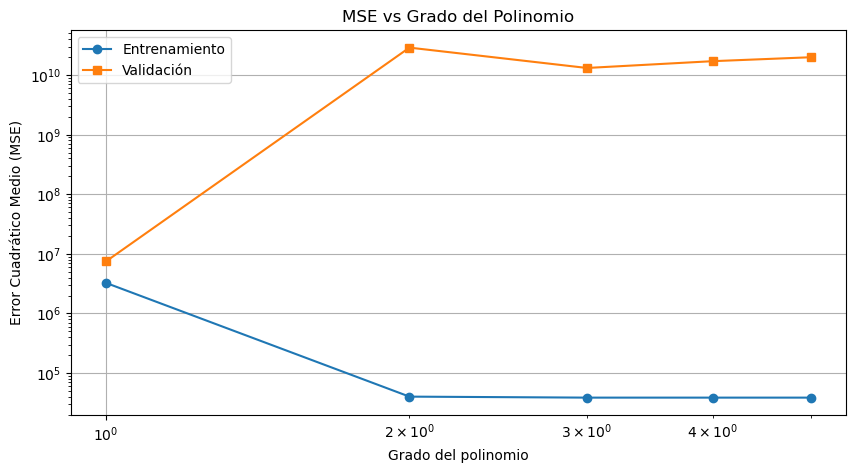

In [8]:
# Lista de grados de polinomio a evaluar
grados = [1, 2, 3, 4, 5]

# Listas para almacenar el MSE promedio de entrenamiento y validación
mse_ent = []
mse_val = []

# Validación cruzada: 5 folds × 10 repeticiones (50 particiones en total)
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

# Evaluar cada grado de polinomio
for grado in grados:
    
    # 1. Crear transformador polinomial de grado 'grado'
    poly = PolynomialFeatures(degree=grado, include_bias=True)
    
    # 2. Normalizar X para evitar que diferencias de escala dominen el modelo
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. Aplicar expansión polinomial a los datos ya normalizados
    X_poly = poly.fit_transform(X_scaled)

    # 4. Inicializar listas para almacenar el MSE de cada fold
    mse_train_fold = []
    mse_val_fold = []

    # 5. Validación cruzada con 50 particiones (5x10)
    for train_idx, val_idx in cv.split(X_poly):
        X_train, X_val = X_poly[train_idx], X_poly[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # 6. Ajustar modelo de regresión lineal (mínimos cuadrados)
        modelo = LinearRegression()
        modelo.fit(X_train, y_train)

        # 7. Predecir y calcular errores
        y_train_pred = modelo.predict(X_train)
        y_val_pred = modelo.predict(X_val)

        mse_train_fold.append(mean_squared_error(y_train, y_train_pred))
        mse_val_fold.append(mean_squared_error(y_val, y_val_pred))

    # 8. Promediar los MSE de los 50 folds y agregarlos a las listas generales
    mse_ent.append(np.mean(mse_train_fold))
    mse_val.append(np.mean(mse_val_fold))

# ---------------------------------
# Visualización de resultados
# ---------------------------------

plt.figure(figsize=(10, 5))
plt.plot(grados, mse_ent, marker='o', label="Entrenamiento")
plt.plot(grados, mse_val, marker='s', label="Validación")
plt.xscale("log")     # Escala logarítmica en eje X (para λ)
plt.yscale("log")     # Escala logarítmica en eje Y (para MSE)
plt.xlabel("Grado del polinomio")
plt.ylabel("Error Cuadrático Medio (MSE)")
plt.title("MSE vs Grado del Polinomio")
plt.legend()
plt.grid(True)
#plt.savefig("MSEvsGrado.png", dpi=300, bbox_inches='tight')
plt.show()

# **SOLUCIÓN INCISO b)**

### Reducción de atributos antes de la expansión polinomial

Cuando se utiliza `PolynomialFeatures` con un **grado elevado (como 20)**, el número de atributos resultantes crece de forma **combinatoria**, lo cual puede llevar fácilmente a un **MemoryError** si la matriz de entrada tiene muchas columnas.

---

#### Esto es un problema ...

La cantidad de columnas generadas por la expansión polinomial de grado $ d $ para $ n $ variables es:

$$
\text{columnas} = \binom{n + d}{d}
$$

Por ejemplo, si \( n = 35 \) y \( d = 20 \):

$$
\binom{55}{20} \approx \text{muy grande} \ \text{(el cálculo está abajo)}
$$

Esto da lugar a matrices de tamaño enorme que no caben en la memoria RAM de ningún equipo común (como mi lap, :c)

---

#### Una posible solución: reducir número de atributos antes de expandir

Una forma efectiva de reducir la complejidad computacional sin violar el enunciado (que exige grado 20), es **quedarse solo con las variables más predictivas**.

Esto se puede hacer con: $SelectKBest$.

In [9]:
# Columnas que se van a crear
# Es un valor bastante grande
import math
math.comb(55,20)

505037289962205

In [10]:
# Separar X e y
X_full = data.drop(columns="price")
y = data["price"]

# Aplicar SelectKBest con el test F (regresión)
selector = SelectKBest(score_func=f_regression, k=6)
X_reducido = selector.fit_transform(X_full, y)

# Obtener nombres de las columnas seleccionadas
columnas_seleccionadas = X_full.columns[selector.get_support()]
print("Mejores columnas seleccionadas:")
print(columnas_seleccionadas.tolist()) # Lista de las columnas con las que se va a trabajar el inciso b)

Mejores columnas seleccionadas:
['width', 'curb-weight', 'num-of-cylinders', 'engine-size', 'horsepower', 'make_encoded']


## Mínimos cuadrados con penalización (Ridge y Lasso)

En esta parte se realiza la regresión utilizando un **polinomio de grado 20** sobre los atributos, pero ahora se agrega un **término de penalización** que limita el tamaño de los coeficientes para evitar el sobreajuste.

---

#### Objetivo

- Aplicar **regresión polinomial de grado 20**.
- Incorporar **penalización por norma L2 (Ridge, [sklearn.linear_model.Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html))** y **norma L1 (Lasso, [sklearn.linear_model.Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html))**.
- Evaluar el desempeño para diferentes valores del parámetro de regularización $ \lambda $ (llamado `alpha` en `scikit-learn`).
- Comparar el **Error Cuadrático Medio (MSE)** en entrenamiento y validación.

---

#### ¿Qué es la regularización?

Cuando el modelo tiene **muchas variables** (como ocurre al expandir a grado 20), puede aprender demasiado bien los datos de entrenamiento y fallar al generalizar. Esto se llama **sobreajuste**.

La regularización **agrega un castigo al tamaño de los coeficientes** $ \beta $, controlado por un parámetro $ \lambda $:

$$
\min_{\beta} \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda \|\beta\|_p
$$

- **Ridge (L2)**: penaliza con la **norma cuadrada**  
  $$ \|\beta\|_2^2 = \sum \beta_i^2 $$
  
- **Lasso (L1)**: penaliza con la **norma absoluta**  
  $$ \|\beta\|_1 = \sum |\beta_i| $$

---

#### ¿Qué se hará?

1. Aplicar `PolynomialFeatures(degree=20)` para generar variables polinomiales.
2. Probar diferentes valores de `alpha`:
   $
   \lambda \in \{0.01, 0.1, 1, 10, 100\}
   $
3. Usar:
   - `Ridge(alpha=λ)` para penalización L2
   - `Lasso(alpha=λ)` para penalización L1
4. Evaluar con validación cruzada de 5 folds repetida 10 veces.
5. Graficar el MSE promedio en entrenamiento y validación para cada $ \lambda $.

---

#### Nota sobre Lasso

Dado que Lasso tiende a **reducir muchos coeficientes a cero**, es especialmente útil cuando queremos **seleccionar atributos relevantes** automáticamente.  
Sin embargo, puede necesitar ajustes finos y más cuidado numérico cuando se usan muchos atributos. Es por ello que este método tarda demasiado en ejecutarse. 

---

In [11]:
def evaluar_modelo_regularizado_subplot(modelo_base, nombre_modelo, grado, ax, X_base, y, lambdas, show_legend=False):
    """
    Función general para evaluar modelos regularizados (Ridge o Lasso) usando:
    - Expansión polinomial
    - Validación cruzada
    - Evaluación de distintos valores de lambda (α)

    Parámetros:
    - modelo_base: clase del modelo, puede ser Ridge o Lasso
    - nombre_modelo: string para mostrar en el título del subplot
    - grado: grado del polinomio a usar para la expansión de características
    - ax: eje (subplot) en el que se graficará el resultado
    - X_base: matriz de características original, sin transformar
    - y: vector de salida (precio)
    - lambdas: lista de valores de α a evaluar
    - show_legend: booleano para mostrar o no la leyenda (solo una vez)
    """

    # Validación cruzada: 5 particiones repetidas 10 veces
    cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

    # Escalar los datos de entrada para normalizar todas las variables
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_base)

    # Expansión polinomial de las variables hasta el grado indicado
    poly = PolynomialFeatures(degree=grado, include_bias=True)
    X_poly = poly.fit_transform(X_scaled)

    # Listas para almacenar los errores promedio por valor de α
    mse_ent = []  # Error en entrenamiento
    mse_val = []  # Error en validación

    # Evaluar cada valor de α (lambda)
    for alpha in lambdas:
        mse_train_fold = []  # Errores por fold de entrenamiento
        mse_val_fold = []    # Errores por fold de validación

        # Dividir en entrenamiento y validación usando los índices del split
        for train_idx, val_idx in cv.split(X_poly):
            X_train, X_val = X_poly[train_idx], X_poly[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            # Instanciar el modelo (Ridge o Lasso)
            modelo = modelo_base(alpha=alpha, max_iter=10000)
            modelo.fit(X_train, y_train)

            # Predecir sobre los conjuntos de entrenamiento y validación
            y_train_pred = modelo.predict(X_train)
            y_val_pred = modelo.predict(X_val)

            # Calcular y almacenar el MSE
            mse_train_fold.append(mean_squared_error(y_train, y_train_pred))
            mse_val_fold.append(mean_squared_error(y_val, y_val_pred))

        # Guardar los promedios de MSE para este valor de α
        mse_ent.append(np.mean(mse_train_fold))
        mse_val.append(np.mean(mse_val_fold))

    # ---------------------------
    # Graficar en el subplot
    # ---------------------------

    ax.plot(lambdas, mse_ent, marker='o', label="Entrenamiento")
    ax.plot(lambdas, mse_val, marker='s', label="Validación")

    # Escala logarítmica en ambos ejes
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Título del gráfico y etiquetas
    ax.set_title(f"{nombre_modelo} - Grado {grado}")
    ax.set_xlabel("λ (alpha)")
    ax.set_ylabel("MSE")
    ax.grid(True)

    # Mostrar la leyenda solo si se especifica
    if show_legend:
        ax.legend()


def norma_L1_o_L2(modelo):
    """
    Función que evalúa el modelo con base a la norma L1 o L2 y grafica los resultados.
    Parámetros: 
    -modelo: nombre del modelo que se quiere ejecutar, en este caso puede recibir 2 nombres; 
        Lasso o Ridge
    """
    # Lista de grados polinomiales a evaluar
    grados = [2, 3, 4, 5, 6, 7, 8, 10, 20]
    
    # Lista de valores de λ (alpha) a evaluar para la regularización
    lambdas = [0.01, 0.1, 1, 10, 100]
    
    # Configurar los subplots
    cols = 3  # Número de columnas en la figura
    rows = (len(grados) + cols - 1) // cols  # Cálculo del número de filas (redondeo hacia arriba)
    
    # Crear figura y ejes para subplots
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()  # Aplanar para recorrer fácilmente

    # Determinar nombre del modelo para usar en títulos y gráficos
    if modelo == Ridge:
        string_modelo = "Ridge"
    else: 
        string_modelo = "Lasso"
        grados = [2, 3, 4]  # Limitar grados para Lasso (es más costoso computacionalmente)

    # Iterar sobre los grados y graficar en cada subplot
    for i, grado in enumerate(grados):
        evaluar_modelo_regularizado_subplot(
            modelo,                   # Clase del modelo: Ridge o Lasso
            string_modelo,           # Nombre para el título del subplot
            grado,                   # Grado polinomial actual
            axes[i],                 # Eje donde se va a graficar
            X_reducido,              # Variables predictoras
            y,                       # Variable objetivo
            lambdas,                 # Lista de alphas
            show_legend=(i == 0)     # Solo mostrar la leyenda en el primer subplot
        )

    # Eliminar subplots vacíos si hay más ejes que grados evaluados
    for j in range(len(grados), len(axes)):
        fig.delaxes(axes[j])

    # Título general del conjunto de subplots
    fig.suptitle(f"{string_modelo}: MSE vs λ para distintos grados polinomiales", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])  # Ajustar el layout sin tapar el título
    plt.show()  # Mostrar figura completa

## Aplicado en Ridge

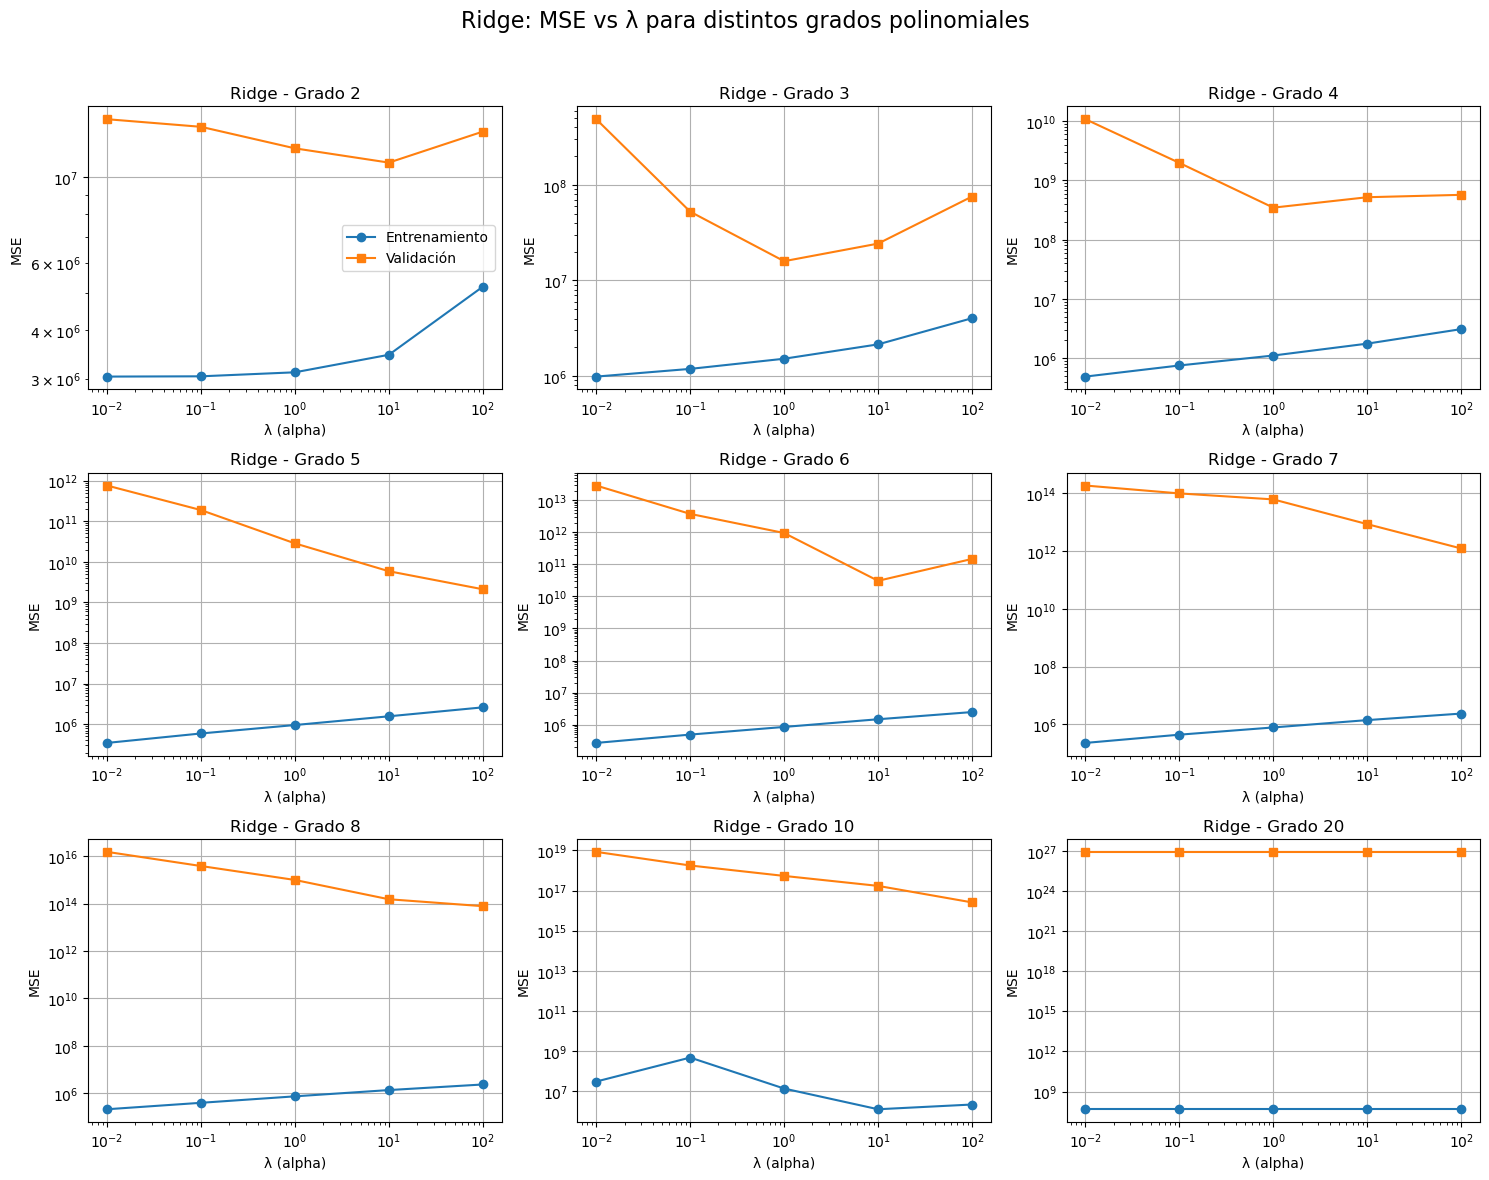

In [12]:
norma_L1_o_L2(Ridge)

## Aplicado en Lasso
### Tarda mucho en ejecutarse, :(
### Solo lo corrí hasta grado 4, con 20 nunca terminaba, :c

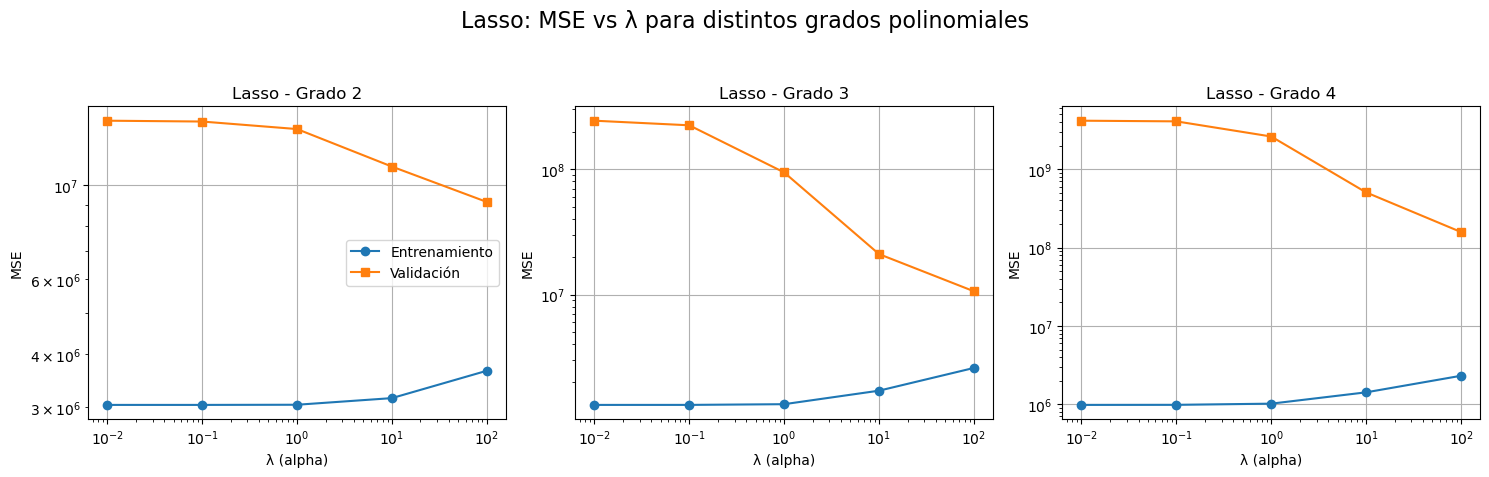

In [13]:
norma_L1_o_L2(Lasso)

#### El hecho de que se tarden en ejecutar los métodos es por el nuevo número de atributos que tiene el data set, esto por la codificación que se eligió. 
#### Si se utiliza otro tipo de ésta, no se garantiza tener resultados buenos, pues se puede estar sesgando el modelo al definir órdenes que ni siquiera existen.

# **SOLUCIÓN INCISO C)**

### ¿Qué es `SelectKBest` y por qué usarlo en este inciso?

`SelectKBest` es una técnica de **selección de características** que nos permite quedarnos con las **k variables más relevantes** del conjunto de datos, basándose en una métrica estadística que mide su relación con la variable objetivo (en este caso, el **precio** del automóvil).

---

#### ¿Cómo funciona?

1. Recibe como entrada:
   - Una **función de puntuación**
   - Un valor **k**, que indica cuántas variables queremos conservar

2. Evalúa **cada variable de forma individual**, asignándole un puntaje.

3. Selecciona las **k variables con mayor puntuación**.

---

### Funciones de puntuación disponibles

#### ¿Qué es `f_regression`?

Es una función de puntuación estadística que calcula:

- La **correlación lineal** entre cada variable y el objetivo (precio)
- Basada en una prueba **F de significancia estadística**
- Se asocia a modelos lineales → perfecta para regresión

---

##### ¿Cómo selecciona atributos?

Para cada atributo \( x_j \), `f_regression` realiza los siguientes pasos:

1. Calcula la **correlación** con la variable objetivo \( y \):
   $$
   r_j = \text{correlación}(x_j, y)
   $$

2. Calcula el **estadístico F** asociado:
   $$
   F_j = \frac{r_j^2}{1 - r_j^2} \cdot (n - 2)
   $$

3. Ordena los atributos por su puntaje y selecciona los **k más significativos**

---

#### ¿Qué es `mutual_info_regression`?

Es una función basada en **teoría de la información**. Calcula cuánta **información mutua** comparte cada variable con la variable objetivo.

- **No asume relaciones lineales**
- Funciona bien cuando hay relaciones **no evidentes o no lineales**
- Usa técnicas de estimación de densidades (como vecinos más cercanos)

Se interpreta como:  
> "¿Cuánta incertidumbre sobre el precio se reduce si conozco esta variable?"

Es ideal cuando sospechamos que las relaciones no son estrictamente lineales.

---

#### ¿Qué es `r_regression`?

Es la función más simple: calcula directamente el **coeficiente de correlación lineal de Pearson** entre cada variable y la salida.

- No usa pruebas estadísticas ni transforma el valor
- Solo da un puntaje en el rango \([-1, 1]\)
- Muy rápida, pero menos robusta

Puede verse como una versión reducida de `f_regression`, sin la prueba F.

---

#### Funciones de puntuación útiles para regresión

| Función | Qué mide | ¿Captura relaciones no lineales? | Ideal para |
|--------|----------|----------------------------|-------------|
| `f_regression` | Correlación lineal + prueba F | No | Modelos lineales |
| `mutual_info_regression` | Información mutua (teoría de la información) | Sí | Datos con relaciones complejas o no lineales |
| `r_regression` | Correlación lineal directa | No | Similar a `f_regression`, sin estadístico F |

Estas funciones influyen directamente en **qué atributos se seleccionan**, y por tanto, en el **rendimiento final del modelo**.

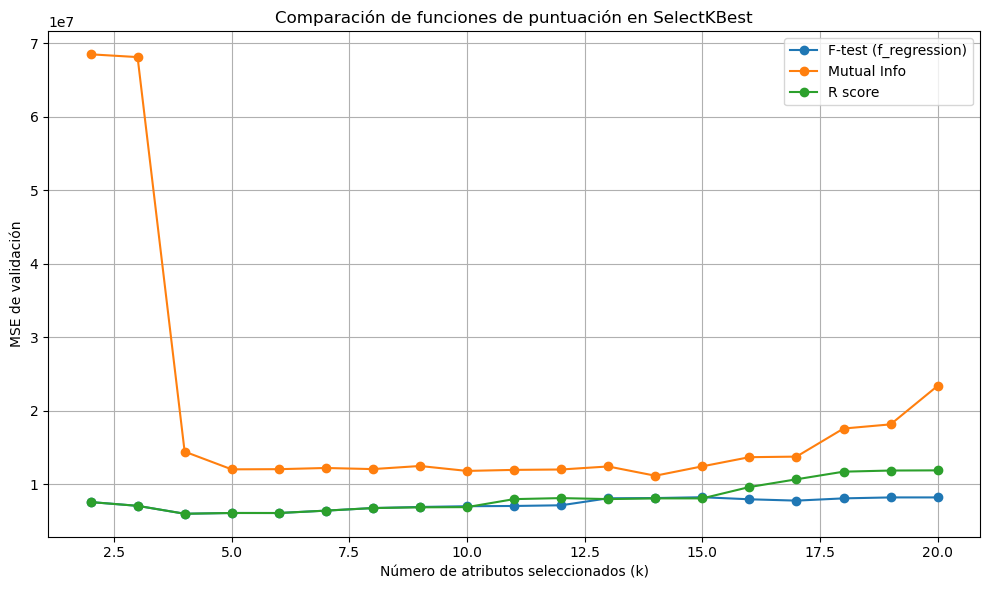

In [14]:
# Variables predictoras y variable objetivo
X_full = data.drop(columns="price")    # Se eliminan los precios para usar solo las variables predictoras
y = data["price"].values               # Se extrae el vector de precios como array de NumPy

# Normalizar las variables predictoras (media 0, varianza 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Expandir las variables con combinaciones polinomiales hasta grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)  # Esto genera muchas nuevas columnas

# Configurar validación cruzada: 5 folds repetidos 10 veces (total 50 evaluaciones por modelo)
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

# Rango de valores de k (número de atributos seleccionados por SelectKBest)
ks = list(range(2, 21))

# Diccionario con las funciones de puntuación a comparar en SelectKBest
funciones = {
    "F-test (f_regression)": f_regression,           # Correlación lineal + prueba F
    "Mutual Info": mutual_info_regression,          # Información mutua entre atributo y target
    "R score": r_regression                         # Correlación lineal simple (como Pearson)
}

# Crear una figura para graficar
plt.figure(figsize=(10, 6))

# Recorremos cada función de puntuación
for nombre, funcion in funciones.items():
    mse_ent = []  # Lista para errores de entrenamiento (no se grafican)
    mse_val = []  # Lista para errores de validación

    for k in ks:
        # Selección de las k mejores variables usando la función actual
        selector = SelectKBest(score_func=funcion, k=k)
        X_kbest = selector.fit_transform(X_poly, y)

        mse_train_fold = []
        mse_val_fold = []

        # Validación cruzada con los atributos seleccionados
        for train_idx, val_idx in cv.split(X_kbest):
            X_train, X_val = X_kbest[train_idx], X_kbest[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            # Entrenar el modelo de regresión lineal
            modelo = LinearRegression()
            modelo.fit(X_train, y_train)

            # Predecir y calcular errores
            y_train_pred = modelo.predict(X_train)
            y_val_pred = modelo.predict(X_val)

            mse_train_fold.append(mean_squared_error(y_train, y_train_pred))
            mse_val_fold.append(mean_squared_error(y_val, y_val_pred))

        # Promediar el MSE en los 50 folds
        mse_ent.append(np.mean(mse_train_fold))
        mse_val.append(np.mean(mse_val_fold))

    # Graficar solo los errores de validación (curvas más relevantes)
    plt.plot(ks, mse_val, marker='o', label=f"{nombre}")

# Configurar el gráfico final
plt.xlabel("Número de atributos seleccionados (k)")
plt.ylabel("MSE de validación")
plt.title("Comparación de funciones de puntuación en SelectKBest")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Comparacion_MSE_SelectKBest.png", dpi=300, bbox_inches="tight")
plt.show()

### ¿Qué es RFE (Recursive Feature Elimination)?

**RFE** es una técnica de selección de atributos supervisada que busca encontrar el subconjunto más relevante de variables para un modelo, eliminando iterativamente las menos importantes.

---

#### ¿Cómo funciona?

1. **Entrena un modelo** (por ejemplo, regresión lineal) con todos los atributos disponibles.
2. **Evalúa la importancia** de cada atributo (según los coeficientes del modelo entrenado).
3. **Elimina la variable menos relevante**.
4. Repite el proceso con el subconjunto restante hasta quedarse con **k variables** seleccionadas.

---

#### Parámetros clave en `RFE` de `scikit-learn`:

- `estimator`: El modelo base (por ejemplo, `LinearRegression()`).
- `n_features_to_select`: Número de variables finales que queremos conservar.
- `step`: Número de variables que se eliminan en cada iteración (más grande = más rápido, pero menos preciso).

---

#### ¿Por qué se usó aquí?

- Tras aplicar una **expansión polinomial de grado 2**, el número de variables creció considerablemente.
- Muchas de estas variables eran combinaciones irrelevantes para predecir el precio.
- Usar `RFE` permitió reducir el conjunto de atributos a los más relevantes **sin necesidad de evaluar cada combinación manualmente**.
- Fue una forma útil de comparar con `SelectKBest`, pero con un enfoque diferente: **RFE evalúa atributos en conjunto**, mientras que `SelectKBest` los evalúa individualmente.

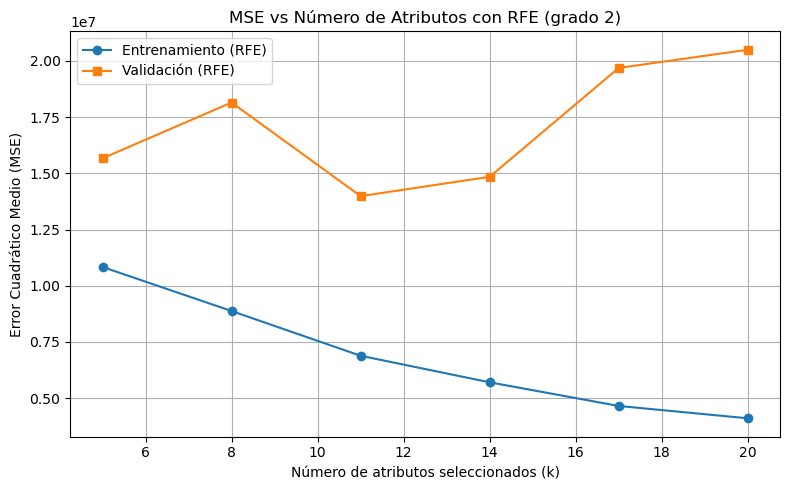

In [15]:
# Variables predictoras (todas menos 'price') y variable objetivo
X_full = data.drop(columns="price")
y = data["price"].values

# Escalar las variables (media 0, desviación estándar 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Aplicar expansión polinomial de grado 2 a las variables escaladas
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# Configurar validación cruzada con menos repeticiones para reducir el tiempo de ejecución
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

# Definir los valores de k que vamos a evaluar (cantidad de atributos seleccionados por RFE)
ks = list(range(5, 21, 3))  # [5, 8, 11, 14, 17, 20]

# Listas para almacenar los errores medios de entrenamiento y validación
mse_ent = []
mse_val = []

# Bucle principal para probar distintos valores de k
for k in ks:
    mse_train_fold = []  # MSE en entrenamiento por fold
    mse_val_fold = []    # MSE en validación por fold

    # Validación cruzada
    for train_idx, val_idx in cv.split(X_poly):
        # Dividir datos según los índices generados por RepeatedKFold
        X_train, X_val = X_poly[train_idx], X_poly[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Aplicar RFE (eliminación recursiva de características)
        modelo_base = LinearRegression()
        rfe = RFE(estimator=modelo_base, n_features_to_select=k, step=5)  # step=5 para que sea más rápido
        X_train_rfe = rfe.fit_transform(X_train, y_train)
        X_val_rfe = rfe.transform(X_val)

        # Entrenar el modelo con las variables seleccionadas
        modelo = LinearRegression()
        modelo.fit(X_train_rfe, y_train)

        # Predecir para entrenamiento y validación
        y_train_pred = modelo.predict(X_train_rfe)
        y_val_pred = modelo.predict(X_val_rfe)

        # Calcular y guardar el MSE
        mse_train_fold.append(mean_squared_error(y_train, y_train_pred))
        mse_val_fold.append(mean_squared_error(y_val, y_val_pred))

    # Guardar el promedio de los errores por cada valor de k
    mse_ent.append(np.mean(mse_train_fold))
    mse_val.append(np.mean(mse_val_fold))

# ----------------------------------------------------
# Graficar resultados MSE vs Número de atributos (k)
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(ks, mse_ent, marker='o', label="Entrenamiento (RFE)")
plt.plot(ks, mse_val, marker='s', label="Validación (RFE)")
plt.xlabel("Número de atributos seleccionados (k)")
plt.ylabel("Error Cuadrático Medio (MSE)")
plt.title("MSE vs Número de Atributos con RFE (grado 2)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("MSEvsK_RFE_Optimizado.png", dpi=300, bbox_inches="tight")
plt.show()

# **DISCUSIÓN Y CONCLUSIONES**

### Codificación y Preprocesamiento

- Se aplicaron distintas técnicas de codificación categórica:
  - **Ordinal Encoding** para atributos con orden lógico.
  - **One-Hot Encoding** para variables sin jerarquía clara.
  - **Target Encoding** en columnas con muchas clases (como `make`), para evitar una explosión en el número de columnas.
  - Estas decisiones de codificación impactaron directamente en el número de variables generadas, afectando tanto el desempeño como la factibilidad de entrenar modelos más complejos. Es importante resaltar que la codificación de variables categóricas no es una tarea trivial: no se trata simplemente de transformar categorías en números, como hacer $f(\text{Chevrolet}) = 1$, $f(\text{Nissan}) = 2$, $f(\text{Tesla}) = 3$.

Este tipo de codificación, aunque sencilla, impone un orden artificial que no necesariamente existe en la realidad. Al asignar números consecutivos a categorías nominales como marcas de automóviles, el modelo podría interpretar que Tesla > Nissan > Chevrolet, lo cual introduce un sesgo no justificado por los datos. En realidad, las marcas no tienen un orden natural que pueda ser representado numéricamente, por lo que este tipo de codificación puede afectar negativamente la capacidad del modelo para aprender relaciones verdaderamente relevantes.

Por este motivo, en variables sin un orden intrínseco se optó por codificadores como One-Hot Encoding o Target Encoding, que evitan imponer jerarquías inexistentes y preservan mejor la neutralidad de la información original. Aunque su costo es, en almacenamiento y por ende en tiempo de ejecución.

---

### Complejidad y Selección de Atributos

- Debido al alto número de variables tras la codificación y la expansión polinomial, fue necesario aplicar técnicas como **SelectKBest** para reducir la dimensionalidad, especialmente en los incisos **b)** y **c)**.
- Esta reducción permitió ejecutar los modelos sin errores de memoria, aunque **sacrificando potencialmente información útil** para la predicción.

---

### Comparativa Ridge vs Lasso

- **Ridge (norma L2)** fue más **rápido y estable**, pero no logró contener el sobreajuste en grados polinomiales altos.
- **Lasso (norma L1)** mostró mejor generalización en grados bajos (2–4), gracias a su capacidad de **eliminar atributos irrelevantes**, aunque con un **alto costo computacional** a partir de grado 5 (más arriba no terminaba la ejecución, :c)
- En ambos métodos, se observó que:
  - A mayor grado, mayor riesgo de sobreajuste.
  - La regularización ayuda, pero **no compensa por completo una mala selección de variables**.

---

### Conclusión Final

- El mejor balance entre complejidad, generalización y eficiencia se logró con **Lasso de grado 3 o 4**, tras una buena selección de atributos.
- La regresión regularizada es poderosa, pero su efectividad depende críticamente del preprocesamiento y la dimensionalidad del conjunto de datos.
- En problemas de alta dimensión como este, **la combinación de codificación adecuada + selección de atributos + regularización** es clave para obtener buenos resultados sin saturar los recursos computacionales.
